## Figure 5 and supplement: Detection of peptides enriched between DCX-R178L ##

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

## Peptide detection between DCX-R178L for called genes ##

Script parses comprehensive list of peptides for called genes, generates bar charts summing number of detected peptides with >2 valid values. Called genes are divided into subplots for comparison.

In [3]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV5_3,DCX_DIV5_2,DCX_DIV5_1,DCX_DIV5_4,R178L_DIV5_2,R178L_DIV5_4,R178L_DIV5_1,R178L_DIV5_5,Proteotypic,Precursor.Charge,...,Standard deviation R178L_DIV5,Valid values,Valid values DCX_DIV5,Valid values R178L_DIV5,Protein.Group,Protein.Ids,Genes,Stripped.Sequence,Modified.Sequence,Precursor.Id
0,NaN,NaN,NaN,12.791167,NaN,NaN,NaN,NaN,1,2,...,NaN,1,1,0,P60660,P60660,MYL6,CDFTEDQTAEFK,(UniMod:1)C(UniMod:6)DFTEDQTAEFK,(UniMod:1)C(UniMod:6)DFTEDQTAEFK2
1,11.507507,NaN,12.075542,18.248590,10.428046,17.431799,11.825650,17.247232,1,2,...,3.632764,7,3,4,P07197,P07197,NEFM,SYTLDSLGNPSAYR,(UniMod:1)SYTLDSLGNPSAYR,(UniMod:1)SYTLDSLGNPSAYR2
2,NaN,10.563988,NaN,12.725901,NaN,12.323781,NaN,11.778011,1,3,...,0.385917,4,2,2,P07197,P07197,NEFM,SYTLDSLGNPSAYRR,(UniMod:1)SYTLDSLGNPSAYRR,(UniMod:1)SYTLDSLGNPSAYRR3
3,15.722906,16.203493,16.129105,13.419486,15.444216,13.309931,15.118758,12.737780,1,2,...,1.330857,8,4,4,Q96JE9,Q96JE9,MAP6,AAADALNR,AAADALNR,AAADALNR2
4,14.532477,14.210603,13.681809,NaN,13.259290,NaN,13.830872,NaN,1,3,...,0.404169,5,3,2,Q7Z460,Q7Z460,CLASP1,AAEEAASTLASSIHPEQCIK,AAEEAASTLASSIHPEQC(UniMod:6)IK,AAEEAASTLASSIHPEQC(UniMod:6)IK3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636,NaN,NaN,NaN,13.932907,NaN,13.158944,NaN,13.241080,1,2,...,0.058079,3,1,2,P78559,P78559,MAP1A,YSAQTDITDDSLDR,YSAQTDITDDSLDR,YSAQTDITDDSLDR2
637,NaN,NaN,NaN,10.423452,NaN,NaN,NaN,6.739173,1,2,...,NaN,2,1,1,P78559,P78559,MAP1A,YSAQTDITDDSLDRK,YSAQTDITDDSLDRK,YSAQTDITDDSLDRK2
638,NaN,10.186907,NaN,NaN,NaN,10.934215,NaN,NaN,1,4,...,NaN,2,1,1,Q96JE9,Q96JE9,MAP6,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR4
639,NaN,NaN,NaN,12.242987,NaN,9.580849,NaN,11.319327,1,2,...,1.229290,3,1,2,Q8NHV4,Q8NHV4,NEDD1,YSVNEGLVAEIER,YSVNEGLVAEIER,YSVNEGLVAEIER2


In [4]:
#Create plots folder

pathmastersheet = Path(askmastersheet)
resultdirectory = str(pathmastersheet.parents[0])+'//Plots'
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
path = newmydir
path

WindowsPath('C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/Curated_Cytoskeleton/Plots')

In [9]:
def plot_detected_peptide_counts_DIV5_by_type(
    df,
    genes,
    threshold=2,
    gene_col="Genes"
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import math

    valid_cols = {
        "WT": "Valid values DCX_DIV5",
        "R178L": "Valid values R178L_DIV5",
    }

    # Allow a single gene as a string
    if isinstance(genes, str):
        genes = [genes]

    # --------------------------------------------------------
    # SUBPLOT LAYOUT
    # --------------------------------------------------------

    n_genes = len(genes)

    # 3 columns; add rows as needed
    ncols = min(3, n_genes)
    nrows = math.ceil(n_genes / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    # --------------------------------------------------------
    # PLOT EACH GENE
    # --------------------------------------------------------

    for i, gene in enumerate(genes):

        ax = axes[i]

        # Find all peptide rows belonging to this gene
        gene_df = df[
            df[gene_col]
            .astype(str)
            .str.upper()
            .eq(gene.upper())
        ].copy()

        if gene_df.empty:
            print(f"WARNING: {gene} not found")

            ax.text(
                0.5,
                0.5,
                f"{gene}\nNot found",
                ha="center",
                va="center"
            )

            ax.set_axis_off()
            continue

        counts = {}

        for label, col in valid_cols.items():

            values = pd.to_numeric(
                gene_df[col],
                errors="coerce"
            )

            counts[label] = (
                values >= threshold
            ).sum()

        # ----------------------------------------------------
        # BAR PLOT
        # ----------------------------------------------------

        bars = ax.bar(
            counts.keys(),
            counts.values()
        )

        ax.set_title(
            gene,
            fontweight="bold"
        )

        ax.set_ylabel("Number of peptides")
        ax.set_xlabel("")

        # Integer y-axis
        ax.yaxis.get_major_locator().set_params(integer=True)

        # Put actual peptide count above each bar
        for bar, value in zip(bars, counts.values()):

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                str(value),
                ha="center",
                va="bottom",
                fontsize=10
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # REMOVE UNUSED PANELS
    # --------------------------------------------------------

    for j in range(n_genes, len(axes)):
        fig.delaxes(axes[j])

    # --------------------------------------------------------
    # OVERALL TITLE
    # --------------------------------------------------------

    fig.suptitle(
        f"Detected peptides at DIV5 "
        f"(valid values ≥ {threshold})",
        fontweight="bold",
        fontsize=14
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    plt.savefig(
        path / f"DCX_DIV5peps_selected_genes_{date}.svg",
        bbox_inches="tight"
    )

    plt.show()

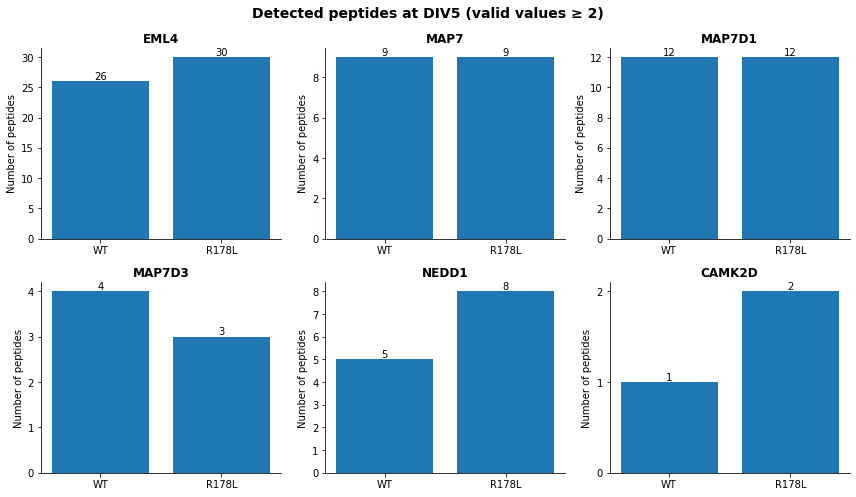

In [10]:
plot_detected_peptide_counts_DIV5_by_type(
    data,
    genes=["EML4","MAP7","MAP7D1","MAP7D3","NEDD1","CAMK2D"]
)

## Specific domain peptides for genes ##

Script requires .csv with additional "DomSpec" column specifying domain features for parsing. Separate files were generated for genes, including EML4_peps_0403, MAP7D1_peps_0403, MAP7_peps_0403, MAPT_peps_0403, and DCX_peps_0403 .csv in supplemental files.

In [13]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV2_3,DCX_DIV2_1,DCX_DIV2_2,DCX_DIV3_2,DCX_DIV3_3,DCX_DIV3_1,DCX_DIV4_2,DCX_DIV4_3,DCX_DIV4_1,DCX_DIV5_3,...,Protein.Group,Protein.Ids,Genes,Stripped.Sequence,Modified.Sequence,Precursor.Id,DomSpec,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,14.863577,15.661263,15.150771,13.950565,13.634607,14.111038,15.586769,15.614600,15.502953,16.762396,...,Q9HC35,Q9HC35,EML4,AALADVLR,AALADVLR,AALADVLR2,N-Term,NaN,NaN,NaN
1,16.435108,17.181288,16.980139,14.206541,14.402372,15.190735,15.982898,15.967092,15.791387,15.866094,...,Q9HC35,Q9HC35,EML4,ADQFLVGTSR,ADQFLVGTSR,ADQFLVGTSR2,TAPE,NaN,NaN,NaN
2,NaN,11.150433,NaN,NaN,NaN,NaN,10.343374,NaN,NaN,NaN,...,Q9HC35,Q9HC35,EML4,AHDGSVFTLCQMR,AHDGSVFTLC(UniMod:6)QM(UniMod:35)R,AHDGSVFTLC(UniMod:6)QM(UniMod:35)R2,TAPE,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Q9HC35,Q9HC35,EML4,AHDGSVFTLCQMR,AHDGSVFTLC(UniMod:6)QM(UniMod:35)R,AHDGSVFTLC(UniMod:6)QM(UniMod:35)R3,TAPE,NaN,NaN,NaN
4,NaN,10.897861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Q9HC35,Q9HC35,EML4,AHDGSVFTLCQMR,AHDGSVFTLC(UniMod:6)QMR,AHDGSVFTLC(UniMod:6)QMR2,TAPE,NaN,NaN,NaN
5,NaN,11.754407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Q9HC35,Q9HC35,EML4,APVSSTESVIQSNTPTPPPSQPLNETAEEESR,APVSSTESVIQSNTPTPPPSQPLNETAEEESR,APVSSTESVIQSNTPTPPPSQPLNETAEEESR4,C-Term,NaN,NaN,NaN
6,14.693019,15.751738,15.201695,12.294787,11.610102,13.021865,14.032269,13.891556,13.967649,NaN,...,Q9HC35,Q9HC35,EML4,ASPSPQPSSQPLQIHR,ASPSPQPSSQPLQIHR,ASPSPQPSSQPLQIHR2,Junction,NaN,NaN,NaN
7,15.675047,16.604258,16.363338,13.849366,13.299752,13.503602,15.376760,15.024642,14.653209,12.694906,...,Q9HC35,Q9HC35,EML4,ATLLEDQQDPSPSS,ATLLEDQQDPSPSS,ATLLEDQQDPSPSS2,C-Term,NaN,NaN,NaN
8,14.428982,15.514282,14.639477,12.644433,NaN,12.903155,13.913244,13.606567,13.641431,13.158163,...,Q9HC35,Q9HC35,EML4,CLAIHPDK,C(UniMod:6)LAIHPDK,C(UniMod:6)LAIHPDK2,N-Term,NaN,NaN,NaN
9,11.605202,13.555392,13.097688,NaN,NaN,NaN,12.276619,11.660638,12.261246,12.605447,...,Q9HC35,Q9HC35,EML4,DGRPLQPHVR,DGRPLQPHVR,DGRPLQPHVR3,TAPE,NaN,NaN,NaN


In [14]:
#Create plots folder

pathmastersheet = Path(askmastersheet)
resultdirectory = str(pathmastersheet.parents[0])+'//Plots'
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
path = newmydir
path

WindowsPath('C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/Peptides/Plots')

In [15]:
## Peptide report plotting: DIV5 WT vs R178L

def plot_profiles_by_class_DIV5_type(df, target_class, fill_value=5):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    gene_col   = "Stripped.Sequence"   # change if needed
    class_col  = "DomSpec"
    type_cols  = ["Mean DCX_DIV5", "Mean R178L_DIV5"]
    type_labels = ["WT", "R178L"]

    # ----------------------------
    # FILTER
    # ----------------------------
    sub = df[df[class_col] == target_class].copy()

    if sub.empty:
        print(f"No data for class: {target_class}")
        return

    # clean
    sub[gene_col] = sub[gene_col].astype(str).str.strip()
    for c in type_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = sub.drop_duplicates(subset=[gene_col], keep="first")

    # ----------------------------
    # PREP DATA
    # ----------------------------
    raw_vals = sub[type_cols].to_numpy(dtype=float)
    nan_mask = np.isnan(raw_vals)

    # fill NaNs for internal handling
    vals = np.where(nan_mask, fill_value, raw_vals)

    x = np.arange(len(type_labels))

    # ----------------------------
    # AXIS SCALING
    # ----------------------------
    ymin = 8
    ymax = 22

    ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1
    ymax += ypad

    bottom_pad = 0.5
    arrow_y = ymin - 0.2

    # ----------------------------
    # PLOT
    # ----------------------------
    fig, ax = plt.subplots(figsize=(4, 4))

    for i, row in enumerate(vals):
        gene = sub.iloc[i][gene_col]

        row_plot = np.maximum(row, ymin)

        ax.plot(x, row_plot, marker="o", linewidth=1.5, alpha=0.8)

        ax.text(
            x[-1] + 0.05,
            row_plot[-1],
            gene,
            fontsize=7,
            va="center"
        )

        if nan_mask[i].any():
            for j in np.where(nan_mask[i])[0]:
                ax.scatter(
                    x[j],
                    arrow_y,
                    marker="v",
                    s=50,
                    color="black",
                    zorder=3
                )

    ax.set_xticks(x)
    ax.set_xticklabels(type_labels, fontweight="bold")
    ax.set_ylim(ymin - bottom_pad, ymax)
    ax.set_xlim(-0.2, len(x) - 1 + 0.8)

    ax.set_title(f"{target_class}", fontweight="bold")
    ax.set_ylabel("Mean intensity")

    ax.axhline(ymin, linestyle="--", linewidth=1, alpha=0.3)

    plt.tight_layout()
    plt.savefig(path / f"EML4_{target_class}_DIV5_WT_vs_R178L_{date}.svg")
    plt.show()

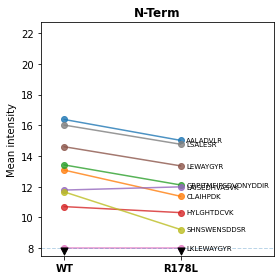

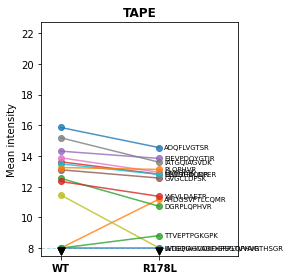

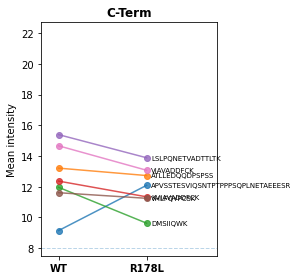

In [18]:
# plot_profiles_by_class_DIV5_type(data, "Junction")
plot_profiles_by_class_DIV5_type(data, "N-Term")
plot_profiles_by_class_DIV5_type(data, "TAPE")
plot_profiles_by_class_DIV5_type(data, "C-Term")